# Selected results: the spymaster, its guesser model, and how it decides

Seven pieces of work, in this order:

1. **The incumbent against a Sonnet spymaster**, with Sonnet guessing for both sides.
2. **Does the prompt change gpt-oss's guesses?** Ranking every word, leaving out the
   number, and asking for one guess at a time.
3. **Association features:** what gpt-oss says a clue makes it think of, used as
   listener inputs.
4. **(Brief) A pure RL spymaster** in place of a listener plus a decision rule.
5. **The pick-index listener** and its R².
6. **Per-pick temperatures:** the best listener that is still fast.
7. **The value of a board state:** from the word counts alone, and from board features,
   with games played by spymasters that use each.

**Terms used throughout.**

- The **listener** is our model of the guesser. For a clue, it gives each word on
  the board a score, and the guesser's next pick is a softmax over the scores of the
  words still on the board. It is a LightGBM booster trained on gpt-oss-120b's
  rankings of 47,223 guesses.
- A **spymaster** searches about 11,000 candidate clues and numbers. For each one it
  asks the listener what the guesser would do, and gives the clue whose predicted
  outcome is best. "Best" is the **decision rule**.
- The **incumbent** (`learned_listener`) is the spymaster frozen in September: the
  first listener, scored by expected own words minus costs for bad words (0.2 neutral,
  1 opponent, 10 assassin).

**Two measures, kept apart.**

- **Listener accuracy** is McFadden R² on one held-out set. It says how well a model
  predicts a guesser. The set is 1,761 generated positions on words no model was
  trained on, ranked by Claude Sonnet 5.5: 4,378 guesses in all.
  - R² = 1 − (the model's log-loss on the guess actually made) / (the log-loss of
    guessing uniformly among the words left).
  - Sonnet is not the guesser the models were trained on, so a gain there is about
    guessing in general, not about gpt-oss's habits.
- **Win rate** says how well a spymaster plays. Every win rate in sections 2–7 comes
  from the same 100 held-out boards, each played twice with the seats swapped.
  gpt-oss-120b guesses for both sides, and the opponent is always the incumbent.
  Section 1 is the one exception, and says so.

Everything is read from stored results: `cache/report/listener_accuracy.csv`,
`cache/report/win_rates.csv`, and the stored games and LLM answers. **The notebook
makes no API calls.**

In [1]:
import json
import sqlite3
import sys
from collections import Counter
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact

ROOT = Path("..").resolve()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts" / "tools"), str(ROOT / "scripts" / "data")]
pd.set_option("display.max_colwidth", 80)

acc = pd.read_csv(ROOT / "cache" / "report" / "listener_accuracy.csv").fillna({"base": ""})
wins = pd.read_csv(ROOT / "cache" / "report" / "win_rates.csv").fillna({"reference": ""})
EVAL, TRAIN = "held-out words, generated, Sonnet 5.5", "train"
PICKS = ["pick_1", "pick_2", "pick_3", "pick_4"]


def ci(x, lo, hi, signed=False):
    f = "{:+.4f}" if signed else "{:.4f}"
    return f"{f.format(x)} [{f.format(lo)}, {f.format(hi)}]"


def accuracy(rows):
    # rows: [(label, group, base, model)]. R² on the eval set with its 95% CI, by pick,
    # the paired gain over the incumbent, and the same model's training R².
    out = []
    for label, group, base, model in rows:
        sel = (acc.group == group) & (acc.base == base) & (acc.model == model)
        e, t = acc[sel & (acc.set == EVAL)].iloc[0], acc[sel & (acc.set == TRAIN)].iloc[0]
        out.append({"model": label,
                    "R² [95% CI]": ci(e.r2, e.r2_lo, e.r2_hi),
                    **{f"pick {p[-1]}{'+' if p == 'pick_4' else ''}": f"{e[p]:.3f}" for p in PICKS},
                    "vs incumbent [95% CI]": ci(e.vs_incumbent, e.vs_lo, e.vs_hi, True),
                    "training R²": f"{t.r2:.4f}"})
    return pd.DataFrame(out).set_index("model")


def win_table(models):
    # One row per spymaster from the gpt-oss suite against the incumbent.
    w = wins.set_index("model").loc[models].reset_index()
    return pd.DataFrame({
        "boards": w.boards.values,
        "win% [95% CI]": [f"{r.win:.1%} [{r.win_lo:.2f}, {r.win_hi:.2f}]" for r in w.itertuples()],
        "boards swept": [f"{r.swept_for} vs {r.swept_against}" for r in w.itertuples()],
        "sign p": w.sign_p.map("{:.3f}".format).values,
        "common boards": w.common_win.map("{:.1%}".format).values,
        "assassin losses": [f"{r.assassin} vs {r.assassin_incumbent}" for r in w.itertuples()],
        "mean number": w.mean_k.map("{:.2f}".format).values,
        "vs reference [95% CI]": ["" if not r.reference else
                                  f"{r.vs_ref:+.1%} [{r.vs_lo:+.1%}, {r.vs_hi:+.1%}] vs {r.reference}"
                                  for r in w.itertuples()],
    }, index=w.model.values)


print(f"{acc[acc.set == EVAL].events.iloc[0]} eval guesses, {acc[acc.set == TRAIN].events.iloc[0]} training guesses")

4378 eval guesses, 47223 training guesses


**How to read a win table.** Each row is one spymaster against the incumbent.

- **win%**: its share of all games on the boards it played both ways.
- **boards swept**: boards it won in both seatings against boards the incumbent
  won in both. The **sign p** is the sign test on those boards. It is the paired
  test, and the one to quote.
- **common boards**: the win rate on only the 44 boards that every spymaster in
  the report played both ways. It checks that the ordering is not an artefact of
  which boards each row kept.
- **assassin losses**: games it lost by its own guesser revealing the assassin,
  against the incumbent's.

## 1. The incumbent against a Sonnet spymaster

**Question.** Can the learned spymaster beat a frontier LLM at the spymaster's job?

**Set-up.**

- **The LLM spymaster** is Claude Sonnet 5 at medium reasoning effort. It is shown
  the board with every card's team and asked for a one-word clue and a number from
  1 to 4.
  - It is told this arena's rules: the guesser takes exactly the number of guesses
    and stops at the first wrong one. The incumbent's reward assumes these rules
    too, so Sonnet is not handicapped by assuming the tabletop ones.
  - It may use any English word. The incumbent searches its ~11,000-word clue pool.
  - The clue legality rule is the same for both. All 755 of Sonnet's clues were
    legal on the first try.
- **The guesser is Sonnet 5 too, for both sides.** This is the one result in the
  notebook not judged by gpt-oss.
- **100 boards** from the held-out vocabulary, each played in both seatings: 200
  games, $7.75.

The setup favours Sonnet. It writes clues for a copy of itself, while the
incumbent's listener was trained on a different model (gpt-oss), so predicting
Sonnet is a transfer test for it.

In [2]:
from codenames.headtohead import game_outcome, paired_summary, side_turn_stats

INC, SON, SUITE = "learned_listener:0e07db5a45d1", "sonnet_spymaster:2e2df3b82215", "dc11e5398f7d0dc4"
con = sqlite3.connect(f"file:{ROOT / 'cache' / 'llm_store.db'}?mode=ro", uri=True)
rows = con.execute("SELECT label, seed, winner, turns FROM game_records WHERE suite_id = ? AND spymaster_id IN (?, ?)",
                   (SUITE, f"A={INC},B={SON}", f"A={SON},B={INC}")).fetchall()
s, t = paired_summary(rows), side_turn_stats(rows)
names = {INC: "incumbent (learned_listener)", SON: "Sonnet 5 spymaster"}
table = pd.DataFrame([{
    "win% [95% CI]": f"{s.win_rate(m):.1%} [{s.wilson(m)[0]:.2f}, {s.wilson(m)[1]:.2f}]",
    "boards swept": s.swept.get(m, 0), "assassin losses": s.assassin.get(m, 0),
    "mean number": f"{t[m].mean_k:.2f}", "own words per clue": f"{t[m].own_per_clue:.2f}",
    "own share of guesses": f"{t[m].own / t[m].guesses:.1%}"} for m in (INC, SON)], index=[names[INC], names[SON]])
n = s.swept.get(INC, 0) + s.swept.get(SON, 0)
sign_p = min(1.0, 2 * sum(comb(n, i) for i in range(min(s.swept.get(INC, 0), s.swept.get(SON, 0)) + 1)) / 2 ** n)
fisher_p = fisher_exact([[s.assassin[INC], s.games - s.assassin[INC]], [s.assassin[SON], s.games - s.assassin[SON]]])[1]
print(f"{s.boards} boards, {s.games} games; sign test on the {n} boards swept one way: p = {sign_p:.3f}; "
      f"assassin losses, Fisher p = {fisher_p:.3f}")
table

100 boards, 200 games; sign test on the 40 boards swept one way: p = 0.017; assassin losses, Fisher p = 0.006


,win% [95% CI],boards swept,assassin losses,mean number,own words per clue,own share of guesses
incumbent (learned_listener),"58.0% [0.51, 0.65]",28,13,2.20,1.67,83.5%
Sonnet 5 spymaster,"42.0% [0.35, 0.49]",12,31,2.24,1.60,80.2%


In [3]:
# How each game ended: did the losing side's own guesser reveal the assassin?
ended = Counter()
for label, seed, winner, turns in rows:
    won, killer = game_outcome(label, winner, turns)
    ended[(names[won], "the loser revealed the assassin" if killer else "otherwise")] += 1
by_end = pd.DataFrame({w: {e: ended[(w, e)] for e in ("the loser revealed the assassin", "otherwise")}
                       for w in names.values()})
by_end.columns = [f"{c} won" for c in by_end.columns]
clean = by_end.loc["otherwise"]
print(f"Games with no assassin: incumbent wins {clean.iloc[0] / clean.sum():.1%} of {clean.sum()}")
by_end

Games with no assassin: incumbent wins 54.5% of 156


,incumbent (learned_listener) won,Sonnet 5 spymaster won
the loser revealed the assassin,31,13
otherwise,85,71


**Reading.**

- **The incumbent wins 58% to 42%,** sweeps 28 boards against Sonnet's 12, and the
  sign test gives p = 0.017.
- **The margin is mostly the assassin.** Sonnet's clues led its own guesser to the
  assassin 31 times, against 13 for the incumbent. In the 156 games where nobody hit
  the assassin, the incumbent wins 54.5%, too small an edge to be significant alone.
  - The incumbent prices the assassin explicitly: a cost of 10 against 1 for each
    own word. A spymaster clueing by intuition does not.
- **Per clue the two are close:** a similar number (2.20 against 2.24) and similar
  own words per clue (1.67 against 1.60).
- **Caveats.** Sonnet played at one effort level (medium). The 95% interval on the
  win rate treats games as independent, but they are paired by board; the sign test
  is the paired comparison.

## 2. Does the way we ask gpt-oss change its guesses?

Every listener is trained on one prompt: show gpt-oss the board and the clue with
its number, and ask it to **rank all the words**. Its first word is read as the
first guess, its second word as the second guess, and so on. That reading is a
choice. A guesser in a real game guesses one word at a time, and knows that its
first guess was right before making its second.

**Set-up.** 300 held-out positions. Each prompt was asked 8 times per position, at
temperature 1.0, giving a small sample of gpt-oss's picks under that prompt.
10,583 calls in all.

| Prompt | What gpt-oss is asked | Its second guess |
|---|---|---|
| `ranked` | Rank **all** the words for the clue and number. *The training prompt.* | The 2nd word of its ranking |
| `ranked_nonumber` | The same, **without the number** | The 2nd word of its ranking |
| `single` | Name the **one** word you would guess first | Asked again, with the first word silently removed |
| `single_feedback` | *(second guess only)* | The first word removed, and told "you already guessed X, and it was correct" |

**Making the second guess comparable.** Each position has one fixed first word: the
first word of the stored training ranking. The `single` prompts remove that word.
For the `ranked` prompts, only the samples that began with that same word are
kept (79%), and their second word is used.

**Found on the way: the training data is close to greedy.** With no temperature in
the request (how all 88,000 stored rankings were bought), DeepInfra answers an
identical prompt identically. So the listener was trained on something close to
gpt-oss's single most likely answer, not samples from its distribution. That is why
these samples set temperature 1.0 explicitly.

**The measure.** At one position, each prompt's 8 picks form a frequency
distribution. **Total variation (TV)** is the share of probability that must move to
turn one into the other (0 = the same, 1 = no word in common). Two samples of 8 from
the *same* distribution already differ, so at each position the two prompts' picks
are pooled and reshuffled 200 times. The mean TV of the reshuffles is the **noise**,
and **excess = TV − noise** is the part caused by the prompt.

In [4]:
from compare_prompt_methods import METHODS, VARIANTS, boot, load, tv, tv_with_null

pos = load(VARIANTS)


def shape(v):
    c = np.array(list(Counter(v).values()), dtype=float) / len(v)
    return c.max(), len(c), float(-(c * np.log2(c)).sum())


def tv_table(step, rng):
    ms, out = METHODS[step], []
    for i, a in enumerate(ms):
        for b in ms[i + 1:]:
            obs, null, mode = [], [], []
            for p in pos.values():
                va, vb = p.get((a, step), []), p.get((b, step), [])
                if len(va) < 2 or len(vb) < 2:
                    continue
                o, n, _ = tv_with_null(va, vb, rng)
                obs.append(o); null.append(n)
                mode.append(Counter(va).most_common(1)[0][0] == Counter(vb).most_common(1)[0][0])
            ex = np.array(obs) - np.array(null)
            lo, hi = boot(ex)
            out.append({"pair": f"{a} vs {b}", "TV": f"{np.mean(obs):.3f}", "noise": f"{np.mean(null):.3f}",
                        "excess [95% CI]": f"{ex.mean():+.3f} [{lo:+.3f}, {hi:+.3f}]",
                        "same top word": f"{np.mean(mode):.0%}", "positions": len(obs)})
    return pd.DataFrame(out).set_index("pair")


rng = np.random.default_rng(0)        # the analysis script's seed and order, so the numbers match it
tv1, tv2 = tv_table(1, rng), tv_table(2, rng)
print(f"{len(pos)} positions, {sum('first' in p for p in pos.values())} with a second guess")

300 positions, 225 with a second guess


### First guess

In [5]:
tv1

,TV,noise,excess [95% CI],same top word,positions
pair,,,,,
ranked vs ranked_nonumber,0.129,0.120,"+0.009 [-0.002, +0.020]",89%,300
ranked vs single,0.148,0.123,"+0.025 [+0.013, +0.038]",87%,300
ranked_nonumber vs single,0.151,0.121,"+0.031 [+0.018, +0.043]",88%,300


### Second guess

In [6]:
tv2

,TV,noise,excess [95% CI],same top word,positions
pair,,,,,
ranked vs ranked_nonumber,0.214,0.208,"+0.007 [-0.010, +0.024]",78%,199
ranked vs single,0.329,0.242,"+0.087 [+0.065, +0.110]",66%,206
ranked vs single_feedback,0.327,0.239,"+0.089 [+0.065, +0.112]",67%,206
ranked_nonumber vs single,0.355,0.243,"+0.112 [+0.087, +0.137]",63%,205
ranked_nonumber vs single_feedback,0.333,0.240,"+0.093 [+0.070, +0.117]",64%,205
single vs single_feedback,0.286,0.236,"+0.050 [+0.033, +0.069]",70%,225


### The shape of each prompt's distribution

The table below is for the second guess. The ranked prompts keep fewer than 8
samples at some positions (only those that began with the fixed first word), and
fewer draws show fewer distinct words. So each prompt is cut down to the same number
of draws as `ranked` at that position, at random with a fixed seed, before the shape
is measured. The positions are those where every prompt had at least that many.

In [7]:
def shape_table(step, matched):
    rng = np.random.default_rng(1)
    res = {m: [] for m in METHODS[step]}
    for p in pos.values():
        n = len(p.get(("ranked", step), []))
        if n < 2 or (matched and any(len(p.get((m, step), [])) < n for m in METHODS[step])):
            continue
        for m in METHODS[step]:
            v = p.get((m, step), [])
            if matched and len(v) > n:
                v = list(rng.choice(v, n, replace=False))
            if len(v) >= 2:
                res[m].append(shape(v))
    return pd.DataFrame({m: dict(zip(["top word's share", "distinct words", "entropy (bits)", ], np.mean(v, 0)),
                                 positions=len(v)) for m, v in res.items()}).T.round(3)


print("First guess (all positions; every prompt has 8 draws):")
display(shape_table(1, matched=False))
print("Second guess, draw counts matched to ranked:")
shape2 = shape_table(2, matched=True)
shape2

First guess (all positions; every prompt has 8 draws):


,top word's share,distinct words,entropy (bits),positions
ranked,0.854,1.733,0.473,300.0
ranked_nonumber,0.849,1.730,0.475,300.0
single,0.852,1.690,0.460,300.0


Second guess, draw counts matched to ranked:


,top word's share,distinct words,entropy (bits),positions
ranked,0.756,2.098,0.744,164.0
ranked_nonumber,0.755,2.128,0.753,164.0
single,0.725,2.415,0.893,164.0
single_feedback,0.723,2.287,0.859,164.0


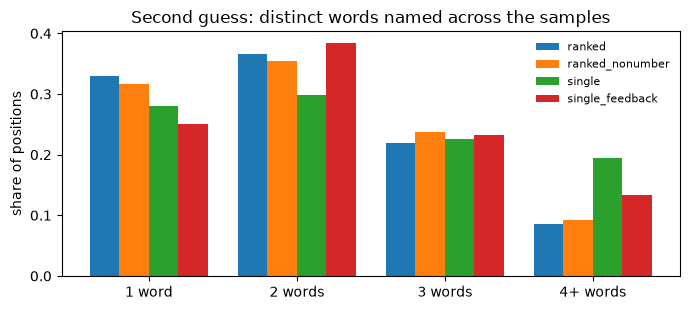

In [8]:
# Second guess: share of positions by the number of distinct words gpt-oss named,
# draw counts matched as above.
rng = np.random.default_rng(1)
dist = {m: Counter() for m in METHODS[2]}
for p in pos.values():
    n = len(p.get(("ranked", 2), []))
    if n < 2 or any(len(p.get((m, 2), [])) < n for m in METHODS[2]):
        continue
    for m in METHODS[2]:
        v = p[(m, 2)]
        v = list(rng.choice(v, n, replace=False)) if len(v) > n else v
        dist[m][min(len(set(v)), 4)] += 1
fig, ax = plt.subplots(figsize=(7, 3.2))
width = 0.2
for i, m in enumerate(METHODS[2]):
    tot = sum(dist[m].values())
    ax.bar(np.arange(4) + (i - 1.5) * width, [dist[m][k] / tot for k in (1, 2, 3, 4)], width, label=m)
ax.set_xticks(range(4), ["1 word", "2 words", "3 words", "4+ words"])
ax.set_ylabel("share of positions")
ax.set_title("Second guess: distinct words named across the samples")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

In [9]:
# The positions where continuing the list and re-asking disagree most.
fmt = lambda v: ", ".join(f"{w} {c}" for w, c in Counter(v).most_common())
scored = sorted(((tv(p[("ranked", 2)], p[("single", 2)]), clue, number, p) for (seed, clue, number), p in pos.items()
                 if len(p.get(("ranked", 2), [])) >= 4 and len(p.get(("single", 2), [])) >= 4), key=lambda x: -x[0])
pd.DataFrame([{"clue": f"{clue.upper()} {number}", "first guess (removed)": p["first"],
               "ranked: continue the list": fmt(p[("ranked", 2)]), "single: re-ask": fmt(p[("single", 2)]),
               "single_feedback": fmt(p[("single_feedback", 2)])} for d, clue, number, p in scored[:5]]).set_index("clue")

,first guess (removed),ranked: continue the list,single: re-ask,single_feedback
clue,,,,
EXPLORING 3,Himalayas,Africa 8,"Mercury 5, Saturn 2, Helicopter 1","Saturn 6, Mercury 2"
CONSISTED 4,Part,"Contract 7, Pumpkin 1","Europe 2, Rome 1, Ice cream 1, Pound 1, Mammoth 1, Cook 1, Pie 1","Europe 3, Contract 3, Pie 1, Pumpkin 1"
ATLANTA 2,Phoenix,Tokyo 6,"Pie 3, Greece 2, Stock 1, Pitch 1, Pumpkin 1","Tokyo 4, Greece 2, Pie 1, Pitch 1"
UNFORTUNATELY 4,Luck,"Slug 3, Hood 1, Well 1, Night 1, Engine 1","Dice 3, Turkey 2, Night 2, Cover 1","Dice 3, Night 2, Mercury 1, Turkey 1, Well 1"
PLAZA 2,London,"Embassy 5, Stadium 1",Stadium 8,"Embassy 5, Stadium 3"


**Reading.**

- **The number does not matter.** With and without it, the two ranked prompts are
  indistinguishable at both guesses (excess +0.009 and +0.007, intervals covering
  zero).
- **The first guess barely depends on the prompt.** Ranking and naming one word
  differ by an excess of +0.025: real (the interval is above zero) but small. They
  share the top word at 87% of positions, and all three distributions have the same
  shape, with the top word taking about 85% of the samples.
- **The second guess depends on how it is asked.** Continuing a list and re-asking
  with the first word removed differ by an excess of about +0.09, and agree on the
  top word at only two-thirds of positions. Being told the first guess was correct
  moves the re-ask again, by about half as much (+0.05).
- **The re-ask is flatter.** With draw counts matched, it names more distinct words
  (2.42 against 2.10) and has higher entropy (0.89 against 0.74 bits). A list keeps
  to the sense its first word chose (EXPLORING: Himalayas, then Africa). A fresh
  question can switch sense (Saturn, Mercury), or scatter when nothing fits well.
- **What this means for the listener.** The incumbent's R² on the second guess is
  about the same under every prompt: 0.301 on `ranked` (what it was trained on),
  0.305 on `single` and 0.278 on `single_feedback` (from
  `compare_prompt_methods.py --booster`, not recomputed here). The
  arena's gpt-oss guesser asks once per turn and reads its ranking from the top, so
  for the arena the ranked continuation is exactly the right data. A human sees the
  first card turned over before guessing again, which `single_feedback` imitates.

**Caveats.** 8 samples per position are enough for the averages, not for any single
position. The ranked second-guess samples are a selected 79%. Excess TV slightly
understates real differences, since the reshuffle assumes the prompts are the same.

## 3. Association features: what a clue makes gpt-oss think of

**The idea.** Embeddings capture how words are used. The guesser is an LLM, and what
it guesses depends on what the clue *reminds it of*. So we asked gpt-oss that
directly, with no board:

> List the 25 words that the word "{clue}" most strongly makes you think of,
> strongest association first. Each entry should be a single common word or a short
> name. Respond with ONLY a JSON array of strings -- no other text.

Each clue was asked **5 times at temperature 1.0**, for every clue in the spymaster's
pool and every board word (the count and cost are printed below). It is free in
play, because every clue the spymaster can give already has its lists.

**Two features per (clue, board word),** matching plurals and ignoring case and
punctuation:

- `assoc_share`: the share of the 5 lists that name the board word;
- `assoc_rank`: the mean over lists of 1 / (its position in the list), 0 where a list
  does not name it. Named first counts far more than named 25th.

Only 0.8% of (clue, board word) pairs are named at all, so the features are sparse
but very specific. An example, the clue *river* against the 400 board words:

In [10]:
from build_assoc_sims import forms
from codenames.listener_training import _assoc_norm

CLUE = "river"
board_words = np.load(ROOT / "cache" / "assoc_sims.npz")["board_words"]
a = sqlite3.connect(f"file:{ROOT / 'cache' / 'associations.db'}?mode=ro", uri=True)
lists = [[_assoc_norm(w) for w in json.loads(ws)] for (ws,) in
         a.execute("SELECT words FROM lists WHERE clue = ? ORDER BY sample", (CLUE,))]
n, words, tin, tout = a.execute("SELECT COUNT(*), COUNT(DISTINCT clue), SUM(prompt_tokens), SUM(completion_tokens) FROM lists").fetchone()
print(f"{n:,} lists for {words:,} words; {tin / 1e6:.1f}M tokens in, {tout / 1e6:.1f}M out "
      f"(${(0.037 * tin + 0.17 * tout) / 1e6:.2f} at gpt-oss-120b's DeepInfra price)\n")
print(f"{len(lists)} lists for '{CLUE}'. The first:\n  " + ", ".join(lists[0]) + "\n")
rows = []
for w in board_words:
    f = forms(w)
    hits = [next((i + 1 for i, x in enumerate(l) if x in f), None) for l in lists]
    named = [h for h in hits if h]
    if named:
        rows.append({"board word": w, "assoc_share": len(named) / len(lists),
                     "assoc_rank": sum(1 / h for h in named) / len(lists), "positions in the lists": hits})
pd.DataFrame(rows).sort_values("assoc_rank", ascending=False).set_index("board word").round(3)

56,049 lists for 11,220 words; 5.9M tokens in, 6.8M out ($1.38 at gpt-oss-120b's DeepInfra price)

5 lists for 'river'. The first:
  water, stream, flow, bank, current, tributary, delta, creek, rapids, flood, bridge, boat, fish, marsh, valley, shore, wetland, erosion, mist, silt, drift, cascade, meadow, brook, gorge



,assoc_share,assoc_rank,positions in the lists
board word,,,
water,1.0,1.000,"[1, 1, 1, 1, 1]"
stream,1.0,0.433,"[2, 3, 3, 2, 2]"
bank,1.0,0.230,"[4, 4, 5, 4, 5]"
bridge,1.0,0.123,"[11, 7, 11, 6, 8]"
fish,0.8,0.088,"[13, 6, None, 12, 9]"
spring,0.6,0.029,"[None, 22, 22, 19, None]"
mouth,0.2,0.012,"[None, None, None, 17, None]"


Water is named first in every list. *Bank* (4th–5th every time) and *Mouth* are
other senses of those words, the river's bank and the river's mouth, which a guesser
has to reach for. *Spring* appears in three lists: a river's source.

**The association profile** (`assoc_profile_listener`) adds 11 more features from
the same lists:

- **How vague the clue is** (the same for every board word): the share of distinct
  words across its 5 lists, how much the lists overlap, and how often they open with
  the same word. Plus norms on the clue itself: rarity, concreteness, how widely it
  is known, word frequency and its number of WordNet senses.
- **Reverse associations** (per board word): from the *board word's* own lists,
  how often they name the clue, how early, and that score's rank on the board.

**Listener accuracy.** Each row adds one block of features to the row above
(rows 1–2 are older feature sets, for reference).

In [11]:
accuracy([
    ("incumbent (44 features)", "features", "", "incumbent"),
    ("+ ConceptNet relations (54)", "features", "", "+ ConceptNet"),
    ("+ free associations: assoc_share, assoc_rank (56)", "features", "", "+ free associations (assoc)"),
    ("+ association profile (67)", "features", "", "+ association profile"),
])

,R² [95% CI],pick 1,pick 2,pick 3,pick 4+,vs incumbent [95% CI],training R²
model,,,,,,,
incumbent (44 features),"0.3205 [0.3031, 0.3383]",0.549,0.201,0.139,0.058,"+0.0000 [+0.0000, +0.0000]",0.4364
+ ConceptNet relations (54),"0.3240 [0.3054, 0.3421]",0.551,0.205,0.143,0.061,"+0.0035 [-0.0002, +0.0071]",0.5174
"+ free associations: assoc_share, assoc_rank (56)","0.3293 [0.3107, 0.3473]",0.558,0.210,0.147,0.068,"+0.0088 [+0.0045, +0.0133]",0.5057
+ association profile (67),"0.3309 [0.3125, 0.3492]",0.560,0.212,0.149,0.064,"+0.0104 [+0.0060, +0.0152]",0.5331


**Games.** The same boosters inside spymasters. Under the incumbent's decision rule
(expected words minus costs), then under the win-probability rule of section 7:

In [12]:
win_table(["+ ConceptNet (conceptnet_listener)", "+ free associations (assoc_feature_listener)",
           "win_prob, ConceptNet booster", "win_prob, assoc booster", "win_prob, assoc profile booster"])

,boards,win% [95% CI],boards swept,sign p,common boards,assassin losses,mean number,vs reference [95% CI]
+ ConceptNet (conceptnet_listener),96,"54.7% [0.48, 0.62]",24 vs 15,0.200,53.4%,11 vs 10,2.19,
+ free associations (assoc_feature_listener),96,"53.1% [0.46, 0.60]",23 vs 17,0.430,52.3%,10 vs 5,2.19,
"win_prob, ConceptNet booster",93,"57.5% [0.50, 0.64]",24 vs 10,0.024,55.7%,25 vs 11,2.62,"+5.5% [-2.2%, +13.2%] vs win_prob, incumbent booster"
"win_prob, assoc booster",99,"59.1% [0.52, 0.66]",28 vs 10,0.005,55.7%,21 vs 10,2.59,"+7.7% [+0.5%, +14.8%] vs win_prob, incumbent booster"
"win_prob, assoc profile booster",90,"57.2% [0.50, 0.64]",20 vs 7,0.019,56.8%,18 vs 9,2.68,"+5.7% [-1.1%, +12.5%] vs win_prob, incumbent booster"


**Reading.**

- **The associations are the largest feature gain on Sonnet:** +0.0053 R² over
  ConceptNet, and the profile adds +0.0016 more. Most of it is in the first guess
  (0.551 → 0.560).
- **It is not only gpt-oss predicting itself.** Sonnet never saw these lists, and
  its guesses are predicted better too. On gpt-oss's own rankings the gain was about
  three times larger, as expected when the lists come from the guesser being
  predicted.
- **Under the old decision rule the gain does not show in games** (53.1%, p = 0.43).
  **Under the win-probability rule it does:** the assoc booster is the strongest
  result on the suite, 59.1%, 28 boards swept against 10, p = 0.005. It also held
  with a second guesser nobody fitted anything to (Nemotron: 28 against 9,
  p = 0.003). Section 7 explains why the decision rule decides whether a better
  listener turns into wins.
- **The profile adds fit, not games:** 57.2% against 59.1% for the assoc booster;
  paired, −1.1 points per game [−7.9, +5.6].
- **A risk worth naming:** a feature built from the evaluation guesser improves the
  fit exactly where the fit is measured against that guesser. The Sonnet R² and the
  Nemotron games are the checks against that.

## 4. (Brief) A pure RL spymaster

Every other spymaster here is two parts: a **listener** (a model of the guesser)
and a **decision rule** that searches clues with it. The alternative is one network,
a **policy**, that maps a board straight to a clue and number, trained on what
actually happens in games. Its appeal: a search finds clues where the listener is
wrong in its favour, while a policy trained on real outcomes cannot be fooled that
way.

Three stages, each playing the suite:

1. **Imitation:** trained to copy the incumbent's clue on 30,000 positions. It
   matches the incumbent's exact clue (out of about 10,700) 52% of the time.
2. **REINFORCE on gpt-oss's reward:** fine-tuned on the per-turn reward that
   gpt-oss's real guesses earned. 275 iterations, about $1.30.
3. **Actor-critic on game results:** the only reward is winning or losing a whole
   game against the incumbent, with a learned value of the board as the critic. 40
   iterations, about $7.50 of games.

In [13]:
win_table(["imitation of the incumbent (imitation_policy)", "+ REINFORCE on gpt-oss reward (gptoss_reward_policy)",
           "actor-critic on game results (win_actor_critic)"])

,boards,win% [95% CI],boards swept,sign p,common boards,assassin losses,mean number,vs reference [95% CI]
imitation of the incumbent (imitation_policy),89,"38.8% [0.32, 0.46]",6 vs 26,0.001,36.4%,16 vs 6,2.31,
+ REINFORCE on gpt-oss reward (gptoss_reward_policy),89,"43.8% [0.37, 0.51]",10 vs 21,0.071,40.9%,15 vs 5,2.08,"+4.9% [-1.8%, +11.6%] vs imitation of the incumbent (imitation_policy)"
actor-critic on game results (win_actor_critic),90,"46.7% [0.40, 0.54]",17 vs 23,0.430,47.7%,24 vs 6,2.50,


**Reading.**

- **No policy beats the incumbent.** The best, the actor-critic, wins 46.7%
  (p = 0.43).
- **RL did learn.** On its own validation games the actor-critic rose from the
  imitation policy's 27% to 48% (86 against 24 seeds, p < 0.001), level with the
  incumbent's 50% on the same seeds, but never above it.
- **What it never learned is caution.** It gets more words per turn than the
  incumbent but hits the assassin more than twice as often (24 losses against 6
  here). An assassin game is rare per turn, so the signal for it in about 110 games
  per iteration is weak.
- **Why it stalls:** one game outcome (or one gpt-oss sample per turn, whose reward
  has a standard deviation of about 2) is too noisy a signal to steer a 10,000-way
  choice of clue in a few thousand steps. The listener-plus-search design gets its
  signal from 47,000 labelled guesses instead.

## 5. The pick-index listener

**The problem it addresses.** The listener scores each word once per clue, and
every pick of the turn uses those same scores (pick 2 is a softmax over the words
left once pick 1 is gone). But gpt-oss is less sure of its later picks: on the eval
set R² falls from 0.55 at pick 1 to 0.06 at pick 4 for the incumbent. One set of
scores is too confident from pick 2 on, and the decision rule reads those later
picks to decide the number.

**The model.** Tell the booster which pick it is scoring. Two features are added:
`x`, the pick index, and `x − k`, how far past the announced number it is. Each pick
is still a softmax over the words left, so the turn's probabilities stay exact, but
the trees can learn a different shape for each pick, not just a flattening.

- **depth k:** trained on picks 1..k of each ranking (47,000 events).
- **depth 9:** also on the picks gpt-oss ranked past the number, up to the 9th
  (159,000 events). The training rankings cover the whole board, so these come
  free.

Scored on picks 1..k, like every listener. Each base feature set is shown with its
plain model, with fixed per-pick temperatures (section 6), and with the pick index:

In [14]:
PICK_ROWS = [("44 features: one score per word", "later picks", "44", "frozen"),
 ("44: + per-pick temperatures", "later picks", "44", "+ per-pick temperatures"),
 ("44: pick index, depth k", "later picks", "44", "pick index, depth k"),
 ("44: pick index, depth 9", "later picks", "44", "pick index, depth 9"),
 ("assoc (56): one score per word", "later picks", "assoc", "frozen"),
 ("assoc: + per-pick temperatures", "later picks", "assoc", "+ per-pick temperatures"),
 ("assoc: pick index, depth 9", "later picks", "assoc", "pick index, depth 9")]
accuracy(PICK_ROWS)

,R² [95% CI],pick 1,pick 2,pick 3,pick 4+,vs incumbent [95% CI],training R²
model,,,,,,,
44 features: one score per word,"0.3229 [0.3050, 0.3407]",0.548,0.206,0.143,0.064,"+0.0023 [-0.0005, +0.0052]",0.5121
44: + per-pick temperatures,"0.3295 [0.3129, 0.3458]",0.548,0.213,0.154,0.089,"+0.0090 [+0.0058, +0.0127]",0.4983
"44: pick index, depth k","0.3329 [0.3160, 0.3495]",0.549,0.220,0.161,0.085,"+0.0124 [+0.0084, +0.0169]",0.5209
"44: pick index, depth 9","0.3331 [0.3156, 0.3498]",0.548,0.218,0.162,0.090,"+0.0126 [+0.0084, +0.0168]",0.5241
assoc (56): one score per word,"0.3293 [0.3107, 0.3473]",0.558,0.210,0.147,0.068,"+0.0088 [+0.0045, +0.0133]",0.5057
assoc: + per-pick temperatures,"0.3350 [0.3178, 0.3516]",0.558,0.216,0.156,0.090,"+0.0145 [+0.0100, +0.0190]",0.4938
"assoc: pick index, depth 9","0.3374 [0.3196, 0.3545]",0.557,0.220,0.163,0.093,"+0.0169 [+0.0119, +0.0217]",0.5222


**Extension: history features.** The pick-index booster knows *which* pick it is
on, but not *which words* were already picked. Adding features of the words picked
so far (their similarity to each candidate) gives the best fit of any model:

In [15]:
accuracy([("assoc: pick index, depth 9", "later picks", "assoc", "pick index, depth 9"),
          ("assoc: pick index + history", "later picks", "assoc", "pick index + history, embeddings")])

,R² [95% CI],pick 1,pick 2,pick 3,pick 4+,vs incumbent [95% CI],training R²
model,,,,,,,
"assoc: pick index, depth 9","0.3374 [0.3196, 0.3545]",0.557,0.220,0.163,0.093,"+0.0169 [+0.0119, +0.0217]",0.5222
assoc: pick index + history,"0.3573 [0.3411, 0.3733]",0.557,0.245,0.203,0.142,"+0.0368 [+0.0302, +0.0435]",0.5667


**In play.** The pick index needs a score vector per pick and per number, so about
10 booster runs per clue instead of 1. It was built into a spymaster that re-scores
only the top 8 clues of the plain search with it. On 100 checked positions, that
picks the same clue and number as re-scoring every clue 99 times. The spymaster
also looks one move ahead at the incumbent's reply (section 7).

In [16]:
win_table(["reply lookahead, assoc booster",
           "reply lookahead, assoc booster + pick index (pick_index_lookahead_listener)"])

,boards,win% [95% CI],boards swept,sign p,common boards,assassin losses,mean number,vs reference [95% CI]
"reply lookahead, assoc booster",91,"56.0% [0.49, 0.63]",25 vs 14,0.108,55.7%,26 vs 8,2.53,"-2.8% [-10.0%, +3.9%] vs win_prob, assoc booster"
"reply lookahead, assoc booster + pick index (pick_index_lookahead_listener)",92,"57.6% [0.50, 0.65]",27 vs 13,0.038,52.3%,27 vs 10,2.52,"+2.4% [-4.7%, +9.4%] vs reply lookahead, assoc booster"


**Reading.**

- **The pick index helps the later picks:** pick 3 goes 0.143 → 0.162 and pick 4
  0.064 → 0.090 on the 44 features, +0.010 R² overall. It beats the per-pick
  temperatures slightly on the 44 features (0.3331 against 0.3295), so the trees
  learn more than a flattening.
- **Depth 9 adds almost nothing on held-out words** (0.3331 against 0.3329 for depth
  k). The extra picks past the number add data, not signal that transfers.
- **Pick 1 is unchanged by all of these,** as it should be.
- **History features are worth twice as much again** (+0.020 over the pick index),
  but cost about 130 booster runs per clue, too slow to play.
- **In games** the pick-index spymaster is significant against the incumbent
  (57.6%, 27 against 13 boards, p = 0.038), but against the same spymaster without
  the pick index it is +2.4 points [−4.7, +9.4], no detectable difference.
- **Training R² is far above eval R²** (about 0.52 against 0.33). The eval set has new
  words and a different guesser, so the gap is mostly transfer, not overfitting
  that more regularisation would fix.

## 6. Per-pick temperatures: the best fast listener

**The model.** Keep one booster score per word, and divide it by a fitted
temperature τ_j at pick j:

$$P(\text{pick } j = w) = \frac{e^{s_w / \tau_j}}{\sum_{v\ \text{left}} e^{s_v / \tau_j}}, \qquad \tau_1 = 1$$

τ > 1 flattens the later picks. Only three numbers are fitted (τ₂, τ₃, τ₄₊), by
maximum likelihood on gpt-oss's validation rankings, and Sonnet never enters the
fit. The booster runs **once per clue**; the temperatures cost nothing.

`profile_temperature_listener` applies this to the association-profile booster
(67 features):

In [17]:
fits = {name: json.loads((ROOT / "cache" / f).read_text()) for name, f in
        [("assoc booster", "sequential_listener_assoc_temperature.json"),
         ("assoc profile booster (profile_temperature_listener)", "sequential_listener_assoc_profile_temperature.json")]}
pd.DataFrame({name: {f"τ pick {j}": float(np.exp(-a)) for j, a in zip(("2", "3", "4+"), f["a"])}
              for name, f in fits.items()}).T.round(2)

,τ pick 2,τ pick 3,τ pick 4+
assoc booster,1.09,1.25,1.42
assoc profile booster (profile_temperature_listener),1.09,1.26,1.41


In [18]:
accuracy([
    ("incumbent", "features", "", "incumbent"),
    ("assoc: one score per word", "later picks", "assoc", "frozen"),
    ("assoc: + per-pick temperatures", "later picks", "assoc", "+ per-pick temperatures"),
    ("assoc: pick index, depth 9 (~10 booster runs per clue)", "later picks", "assoc", "pick index, depth 9"),
    ("profile: one score per word", "later picks", "profile", "frozen"),
    ("profile: + per-pick temperatures (profile_temperature_listener)", "later picks", "profile",
     "+ per-pick temperatures (profile_temperature_listener)"),
])

,R² [95% CI],pick 1,pick 2,pick 3,pick 4+,vs incumbent [95% CI],training R²
model,,,,,,,
incumbent,"0.3205 [0.3031, 0.3383]",0.549,0.201,0.139,0.058,"+0.0000 [+0.0000, +0.0000]",0.4364
assoc: one score per word,"0.3293 [0.3107, 0.3473]",0.558,0.210,0.147,0.068,"+0.0088 [+0.0045, +0.0133]",0.5057
assoc: + per-pick temperatures,"0.3350 [0.3178, 0.3516]",0.558,0.216,0.156,0.090,"+0.0145 [+0.0100, +0.0190]",0.4938
"assoc: pick index, depth 9 (~10 booster runs per clue)","0.3374 [0.3196, 0.3545]",0.557,0.220,0.163,0.093,"+0.0169 [+0.0119, +0.0217]",0.5222
profile: one score per word,"0.3309 [0.3125, 0.3492]",0.560,0.212,0.149,0.064,"+0.0104 [+0.0060, +0.0152]",0.5331
profile: + per-pick temperatures (profile_temperature_listener),"0.3372 [0.3201, 0.3534]",0.560,0.219,0.159,0.089,"+0.0167 [+0.0119, +0.0212]",0.5186


**Reading.**

- **R² 0.3372 [0.320, 0.353]: level with the assoc pick-index model (0.3374)**, at
  one booster run per clue instead of about ten. Over the incumbent it is +0.017
  [+0.012, +0.021].
- **The fitted temperatures grow with the pick** (1.09, 1.26, 1.41) and are almost
  identical for the two boosters. The flattening is a property of gpt-oss's later
  picks, not of one booster.
- **The gain is all in the later picks:** pick 4 goes 0.064 → 0.089, and pick 1 is
  unchanged by construction.
- **It makes the spymaster less greedy.** On 30 opening boards its mean number is
  2.73, against 3.10 with the same booster and no temperatures, at about 1.0 s per
  clue. The win-probability rule bids higher numbers when the listener is
  overconfident about later picks, and the temperatures correct exactly that.
- **Not yet played on the suite.** The nearest played result is the per-pick
  temperatures with the incumbent's booster and decision rule (44.3%, 8 boards swept
  against 19, p = 0.05).
  That came before the win-probability rule, under which the later-pick
  probabilities matter far more.

## 7. The value of a board state

The incumbent scores a clue by one turn: expected own words minus costs. That cannot
see **tempo**. Finding 2 words now matters more when it leaves you 1 word from
winning. The **win-probability rule** instead scores a clue by the probability of
winning after the turn it produces:

$$P(\text{win} \mid \text{clue}, k) = \sum_{\text{endings } e} P(e \mid \text{clue}, k)\; W(e)$$

The listener gives P(e), how the turn ends: j own words, then a neutral, opponent or
assassin word, or all k found. W(e) is the value of the position that ending leaves.
Two ways to estimate it:

### 7a. From the word counts alone: V(a, b)

**V(a, b)** = P(the side to move wins | it has a words left, the other side has b).
It is estimated from 10,266 finished gpt-oss games (86,287 turn states), each cell
shrunk toward a logistic fit and then made monotone, so that finding more of your
own words can never lower the value.

86287 turn states


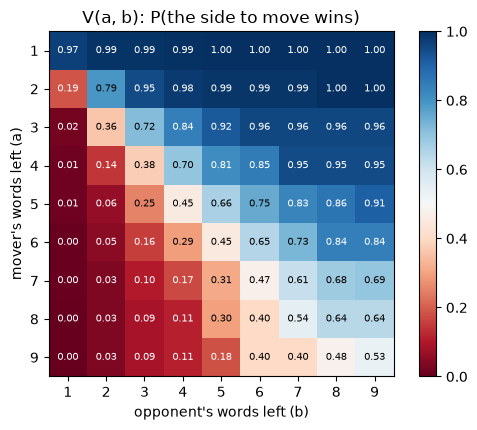

In [19]:
z = np.load(ROOT / "cache" / "win_value.npz")
V = pd.DataFrame(z["V"][1:, 1:], index=pd.Index(range(1, 10), name="mover's words left (a)"),
                 columns=pd.Index(range(1, 10), name="opponent's words left (b)"))
fig, ax = plt.subplots(figsize=(5.6, 4.4))
im = ax.imshow(V.values, cmap="RdBu", vmin=0, vmax=1, origin="upper")
for i in range(9):
    for j in range(9):
        ax.text(j, i, f"{V.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(V.values[i, j] - 0.5) > 0.3 else "black")
ax.set_xticks(range(9), V.columns); ax.set_yticks(range(9), V.index)
ax.set_xlabel(V.columns.name); ax.set_ylabel(V.index.name)
ax.set_title("V(a, b): P(the side to move wins)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
print(f"{int(z['n'].sum())} turn states")

Tempo is worth a lot: at 2 words each the side to move wins 0.79, and at 4 each,
0.70. The starting position (9 against 8) is 0.48 for the first mover.

**Spymasters using V** (`win_prob_listener`). Each row is the same decision rule,
with a different listener booster:

In [20]:
win_table(["win_prob, incumbent booster", "win_prob, is-a booster", "win_prob, ConceptNet booster",
           "win_prob, assoc booster"])

,boards,win% [95% CI],boards swept,sign p,common boards,assassin losses,mean number,vs reference [95% CI]
"win_prob, incumbent booster",98,"51.5% [0.45, 0.58]",17 vs 14,0.720,54.5%,31 vs 9,2.68,
"win_prob, is-a booster",96,"53.1% [0.46, 0.60]",22 vs 16,0.418,56.8%,31 vs 7,2.63,"+2.1% [-4.2%, +8.9%] vs win_prob, incumbent booster"
"win_prob, ConceptNet booster",93,"57.5% [0.50, 0.64]",24 vs 10,0.024,55.7%,25 vs 11,2.62,"+5.5% [-2.2%, +13.2%] vs win_prob, incumbent booster"
"win_prob, assoc booster",99,"59.1% [0.52, 0.66]",28 vs 10,0.005,55.7%,21 vs 10,2.59,"+7.7% [+0.5%, +14.8%] vs win_prob, incumbent booster"


**Reading.**

- **The rule alone is not the gain.** With the incumbent's own booster, V is level
  with the incumbent (51.5%, 17 against 14 boards).
- **The rule plus a better listener is.** Win rate rises with every listener
  improvement, to 59.1% with the assoc booster (p = 0.005, which survives a
  Bonferroni correction over the 5 arms of this design). Assassin losses fall at
  every step: 31, 31, 25, 21.
- **Why they interact.** The old rule used the listener mostly to *rank* clues. The
  new one uses its probabilities directly: how likely the turn reaches k, and how
  likely it hits the assassin. That pushes the number up (mean 2.6 against the
  incumbent's 2.3), and a worse listener's errors on bigger numbers cost games.
- **The price is the assassin,** about twice the incumbent's rate. Most of it is a
  deliberate trade (the spymaster chose clues its listener rated riskier); part is
  the listener under-predicting the risk on the clues the search favours.

### 7b. From board features: a board-reading V

V(a, b) cannot tell which words are left. Two positions with the same counts can
differ a lot: your remaining words may be easy to clue together, or one may sit
next to the assassin. The board-reading V adds a correction learned from board
features:

$$W = 1 - \sigma\big(\operatorname{logit} V(b, a') + f(\text{board after the turn})\big)$$

- **Features of each side's remaining words**, from the clue pool's similarity
  tables: the cleanest k-word clue's margin over the nearest non-own word, the worst
  and mean single-word margins, and how easily an own word and the assassin share a
  clue.
- **f is a GBT** started from the count table's logit, so it learns only the
  correction.
- **Trained on simulated games**, which cost compute only: gpt-oss is replaced by
  our own listener, sampling its guesses. 6,994 games on 3,498 boards. The simulator matches
  gpt-oss's game statistics except the assassin, which it hits less often.

**Does the board predict wins beyond the counts?** Yes, a little. Log-loss gain
from the board term, out of fold, with a 95% interval over boards (from
`eval_board_value.py` and `eval_sim_value.py`, not recomputed here):

| fitted on | evaluated on | log-loss gain |
|---|---|---|
| real gpt-oss games | real gpt-oss games (out of fold) | +0.0039 [+0.0011, +0.0070] |
| simulated games | simulated games (out of fold) | +0.0055 [+0.0037, +0.0073] |
| **simulated games** | **real gpt-oss games, never seen** | **+0.0043 [+0.0011, +0.0074]** |

The correction learned in simulation predicts real outcomes as well as one fitted on
them. Within a score cell it moves V by a standard deviation of 0.05, more than the
gap between the top clues. Its most-used features are how close each side's words
are to the assassin.

**Spymasters using it** (`board_value_listener`). The only difference from
`win_prob_listener` with the incumbent booster is the value function, so the games
are paired by board. First in simulation (both against the incumbent, the guesser
our sampling listener):

In [21]:
from compare_sim_runs import SIM_DB, per_board


def sim_pair(base, other, what):
    A, _ = per_board(SIM_DB, base, "learned_listener")
    B, _ = per_board(SIM_DB, other, "learned_listener")
    seeds = sorted(set(A) & set(B))
    wa, wb = (np.array([X[s][0] for s in seeds], dtype=float) for X in (A, B))
    d = wb - wa
    boot = d[np.random.default_rng(0).integers(0, len(d), (5000, len(d)))].mean(1) / 2
    up, down = int((d > 0).sum()), int((d < 0).sum())
    p = min(1.0, 2 * sum(comb(up + down, i) for i in range(min(up, down) + 1)) / 2 ** (up + down))
    return {"boards": what, "n": len(seeds), "V(a, b)": f"{wa.mean() / 2:.1%}", "board V": f"{wb.mean() / 2:.1%}",
            "difference per game [95% CI]": f"{d.mean() / 2:+.1%} [{np.percentile(boot, 2.5):+.1%}, "
                                            f"{np.percentile(boot, 97.5):+.1%}]",
            "boards better / worse (sign p)": f"{up} / {down} ({p:.2f})",
            "assassin losses": f"{sum(A[s][1] for s in seeds)} / {sum(B[s][1] for s in seeds)}"}


pd.DataFrame([sim_pair("sim_v1", "sim_bv1", "the board model's own training boards"),
              sim_pair("sim_v1_fresh", "sim_bv1_fresh", "fresh boards")]).set_index("boards")

,n,"V(a, b)",board V,difference per game [95% CI],boards better / worse (sign p),assassin losses
boards,,,,,,
the board model's own training boards,1000,55.5%,58.4%,"+2.9% [+0.5%, +5.1%]",246 / 202 (0.04),240 / 247
fresh boards,600,53.7%,53.1%,"-0.6% [-3.8%, +2.6%]",144 / 150 (0.77),180 / 165


Then with gpt-oss, on the suite:

In [22]:
win_table(["win_prob, incumbent booster", "board-reading V (board_value_listener)"])

,boards,win% [95% CI],boards swept,sign p,common boards,assassin losses,mean number,vs reference [95% CI]
"win_prob, incumbent booster",98,"51.5% [0.45, 0.58]",17 vs 14,0.720,54.5%,31 vs 9,2.68,
board-reading V (board_value_listener),88,"51.1% [0.44, 0.58]",13 vs 11,0.839,47.7%,35 vs 9,2.59,"-1.1% [-8.0%, +6.3%] vs win_prob, incumbent booster"


**Reading.**

- **On its own training boards the board V wins** (+2.9 points, p = 0.04). **On
  fresh boards the gain is gone** (−0.6 [−3.8, +2.6]), and gpt-oss agrees (−1.1
  points [−8.0, +6.3]). The board features describe a board finely enough to
  identify it, so a policy scored on the training boards benefits from what the
  model memorised. That was caught only because the fresh-board run was added.
- **Better prediction did not become better decisions.** The term predicts real
  outcomes better on boards it never saw. But within one move, the after-boards of
  the candidate clues differ only slightly in its features, and the search takes the
  best of 200 clues. Its differences between them are as much error as signal: the
  same optimiser's curse that affects the listener.
- **What followed.** Instead of *learning* what a board is worth, the next model
  *computes* it: the incumbent is code, so its reply on the board our clue leaves
  can be simulated (`reply_lookahead_listener`, 56.0%). That is a one-move search,
  not a value estimate. It also ties `win_prob_listener` with the same booster, so V(a, b)
  remains the value the best spymasters use.

## Caveats

- **About 90–100 boards per spymaster.** A 95% interval on one win rate is about ±7
  points, so differences of 2–3 points between rows cannot be resolved. With many
  rows, one or two sign tests at p < 0.05 are expected by chance; the p-values are
  not corrected except where stated.
- **gpt-oss is both the guesser the listeners were trained on and the guesser in
  the games.** That is why section 1 (Sonnet guessing), the Sonnet R², and the
  Nemotron runs in section 3 matter: they are the checks that a gain is not specific
  to gpt-oss. People pass when unsure and gpt-oss does not, so these win rates may
  understate cautious spymasters.
- **Boards drop out when gpt-oss returns no usable ranking** (up to 13 per row), so
  rows have slightly different boards. The common-boards column checks this.
- **R² intervals are a bootstrap over boards**; every eval position is on its own
  board.
- **Training R² of the incumbent** is on data it was partly early-stopped on, so it
  is not comparable to the other rows' training R². Its eval R² is.
- **Two tables quote stored script outputs** instead of recomputing them: the
  listener R² per prompt in section 2, and the board-value log-loss gains in 7b
  (12 minutes to recompute). The scripts are named where they appear.